# Decision Tree

## Assignment

- Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.
- Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.
3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.
4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).
5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.
6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features
- Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?


## Task 1. Data Preparation
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay
)

In [2]:
df = pd.read_csv("Heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [3]:
df.shape

(999, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


## Task 2. Exploratory Data Analysis (EDA)
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.

### EDA

In [5]:
# EDA
# DATA CLEANING
df.isnull().sum()

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64

In [6]:
# Standardize column names (strip whitespace, lowercase)
df.columns = [c.strip() for c in df.columns] # To remove Extra spaces like (' LB ' → 'LB')
df.columns = [c.replace(' ', '_') for c in df.columns]
df.columns = [c.upper() for c in df.columns]  # Optional: making uppercase for consistency
df.head()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALCH,EXANG,OLDPEAK,SLOPE,THAL,NUM
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [7]:
# Missing values: check counts and percentage
missing_count = df.isna().sum()
missing_pct = 100 * missing_count / len(df)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['Missing_Count', 'Missing_Percentage']
display(missing_summary.sort_values('Missing_Count', ascending=False))

,Missing_Count,Missing_Percentage
OLDPEAK,153,15.315315
AGE,91,9.109109
SEX,91,9.109109
CP,91,9.109109
TRESTBPS,91,9.109109
CHOL,91,9.109109
FBS,91,9.109109
RESTECG,91,9.109109
THALCH,91,9.109109
EXANG,91,9.109109


In [8]:
#  Handling missing values (strategies):
# - If a column has many missing values (>30%), consider dropping it or investigating.
# - For numeric features: impute with mean/median or use KNN/imputer (demonstrated with median).
# - For a small number of rows with missing values: drop rows.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isna().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# if any non-numeric categorical columns have NaNs, fill with 'Unknown'
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)

C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_392\1727052433.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Kaustubh Jadhav\AppData\Local\Temp\ipykernel_392\1727052433.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [9]:
# Convert types if needed (e.g., numeric stored as strings)
# Attempt to coerce non-numeric columns to numeric where appropriate
for col in df.columns:
    if df[col].dtype == object:
        coerced = pd.to_numeric(df[col], errors='coerce')
        non_na_ratio = coerced.notna().sum() / len(coerced)
        # If large fraction converts to numeric, replace column
        if non_na_ratio > 0.5:
            df[col] = coerced

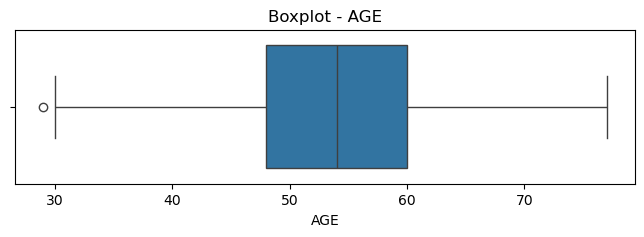

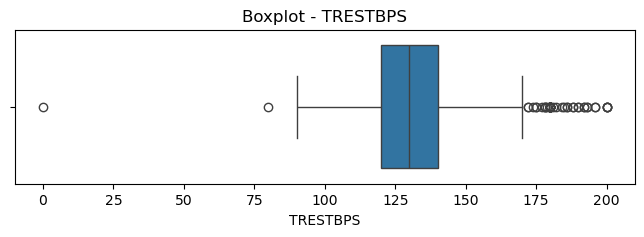

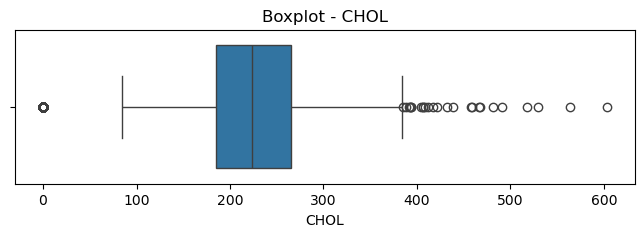

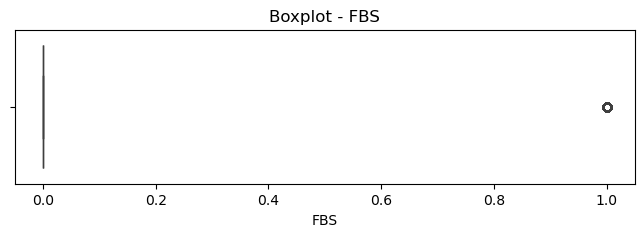

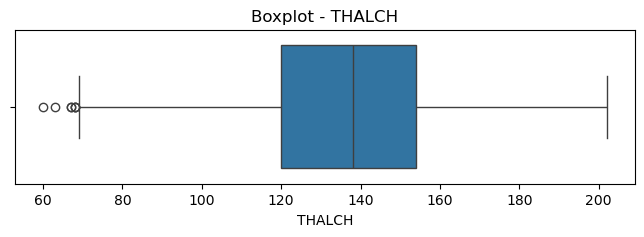

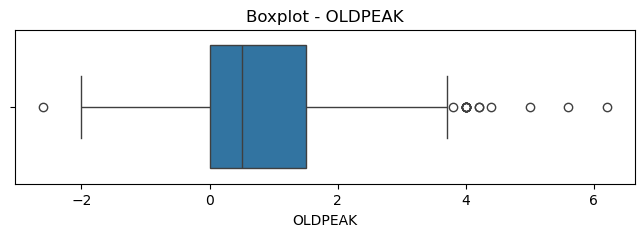

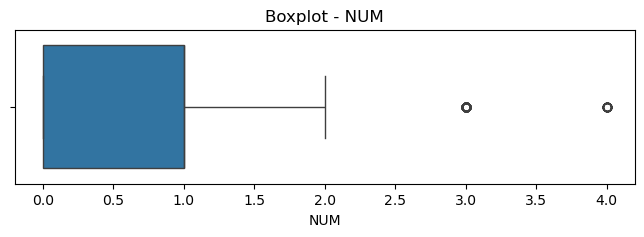

In [10]:
# Outlier detection (visual and z-score based)
# Display boxplots for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

In [11]:
### Z-score method to flag extreme outliers (|z| > 3)
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)
# Count outliers per column:
outlier_counts = pd.DataFrame(outlier_mask, columns=num_cols).sum().sort_values(ascending=False)
display(outlier_counts)

OLDPEAK     15
TRESTBPS    11
CHOL         3
AGE          0
FBS          0
THALCH       0
NUM          0
dtype: int64

In [12]:
Outlier_count = pd.DataFrame(outlier_mask, columns=num_cols).sum()
Outlier_pct = 100 * Outlier_count / len(df)
Outlier_summary = pd.concat([Outlier_count, Outlier_pct], axis=1)
Outlier_summary.columns = ['Outlier_Count', 'Outlier_Percentage']
display(Outlier_summary.sort_values('Outlier_Count', ascending=False))

,Outlier_Count,Outlier_Percentage
OLDPEAK,15,1.501502
TRESTBPS,11,1.101101
CHOL,3,0.300300
AGE,0,0.000000
FBS,0,0.000000
THALCH,0,0.000000
NUM,0,0.000000


In [13]:
# Handling outliers by capping (winsorization) at 1st and 99th percentiles
def winsorize_series(s, lower_pct=0.01, upper_pct=0.99):
    lower = s.quantile(lower_pct)
    upper = s.quantile(upper_pct)
    return s.clip(lower, upper)

df_winsor = df.copy()
for col in num_cols:
    df_winsor[col] = winsorize_series(df_winsor[col], 0.01, 0.99)

In [14]:
df.isna().sum()

AGE          0
SEX          0
CP           0
TRESTBPS     0
CHOL         0
FBS         91
RESTECG      0
THALCH       0
EXANG        0
OLDPEAK      0
SLOPE        0
THAL         0
NUM          0
dtype: int64

In [15]:
# Replace missing FBS with most frequent value (mode)
df['FBS'] = df['FBS'].fillna(df['FBS'].mode()[0])

# Check missing values
print( "So, Null values in FBS is ",df['FBS'].isnull().sum())

So, Null values in FBS is  0


### Visulization the distribution of features

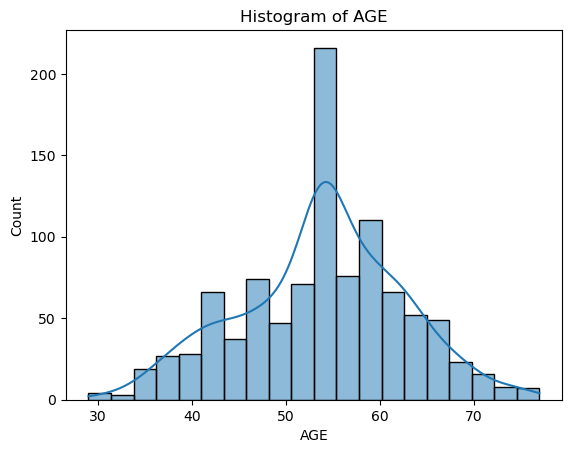

Skewness: -0.1497576706742127
Data is negatively Skewed


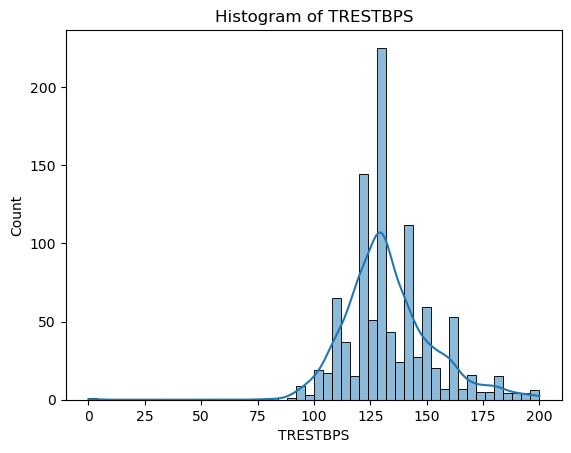

Skewness: 0.416577175078839
Data is Positively Skewed


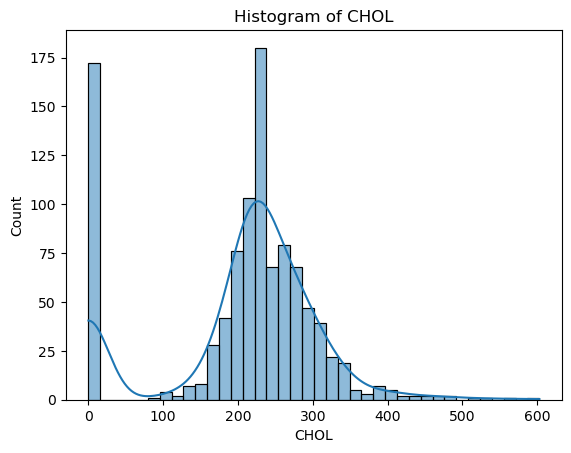

Skewness: -0.644820439232531
Data is negatively Skewed


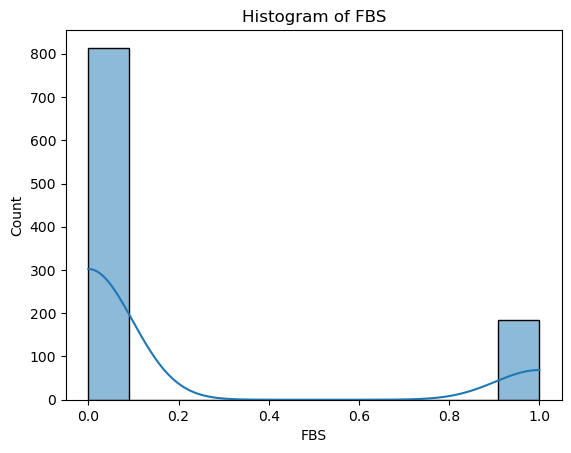

Skewness: 1.6208864017175078
Data is Positively Skewed


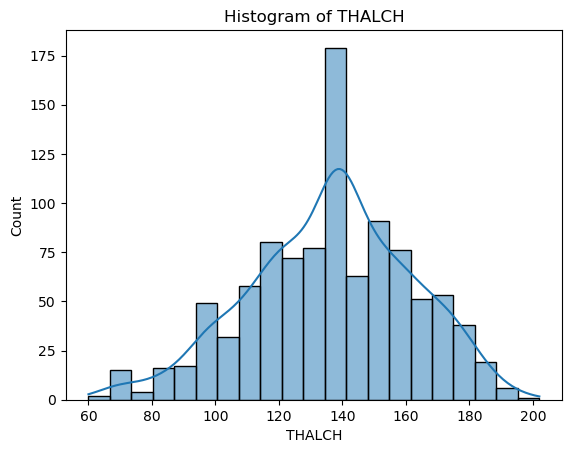

Skewness: -0.2515373508522456
Data is negatively Skewed


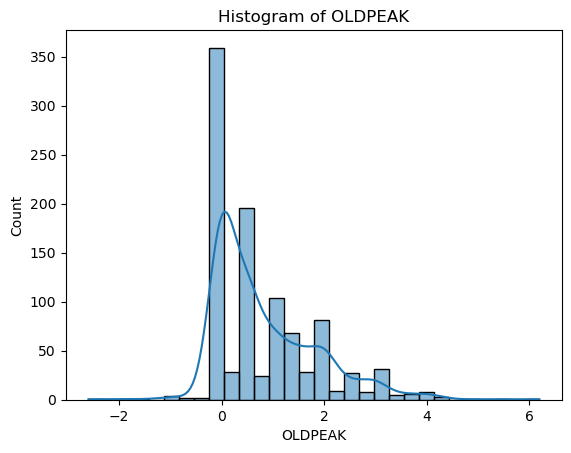

Skewness: 1.2448760090960593
Data is Positively Skewed


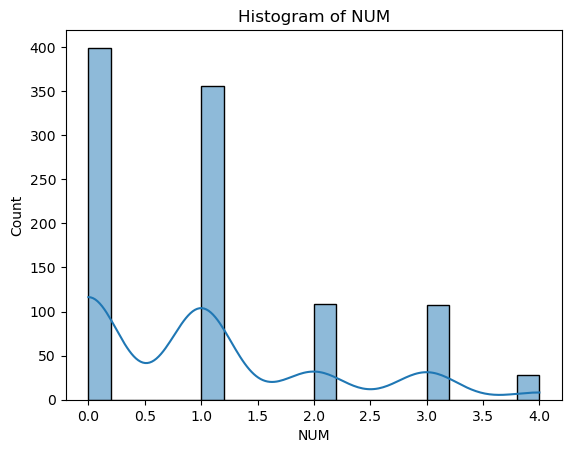

Skewness: 0.9984961152168442
Data is Positively Skewed


In [16]:
from scipy import stats as st
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.show()
    sk=st.skew(df[col])
    print("Skewness:",sk)
    if sk == 0:
        print("Data is Symmetric")
    else:
        if sk > 0:
            print("Data is Positively Skewed")
        else:
            print("Data is negatively Skewed")

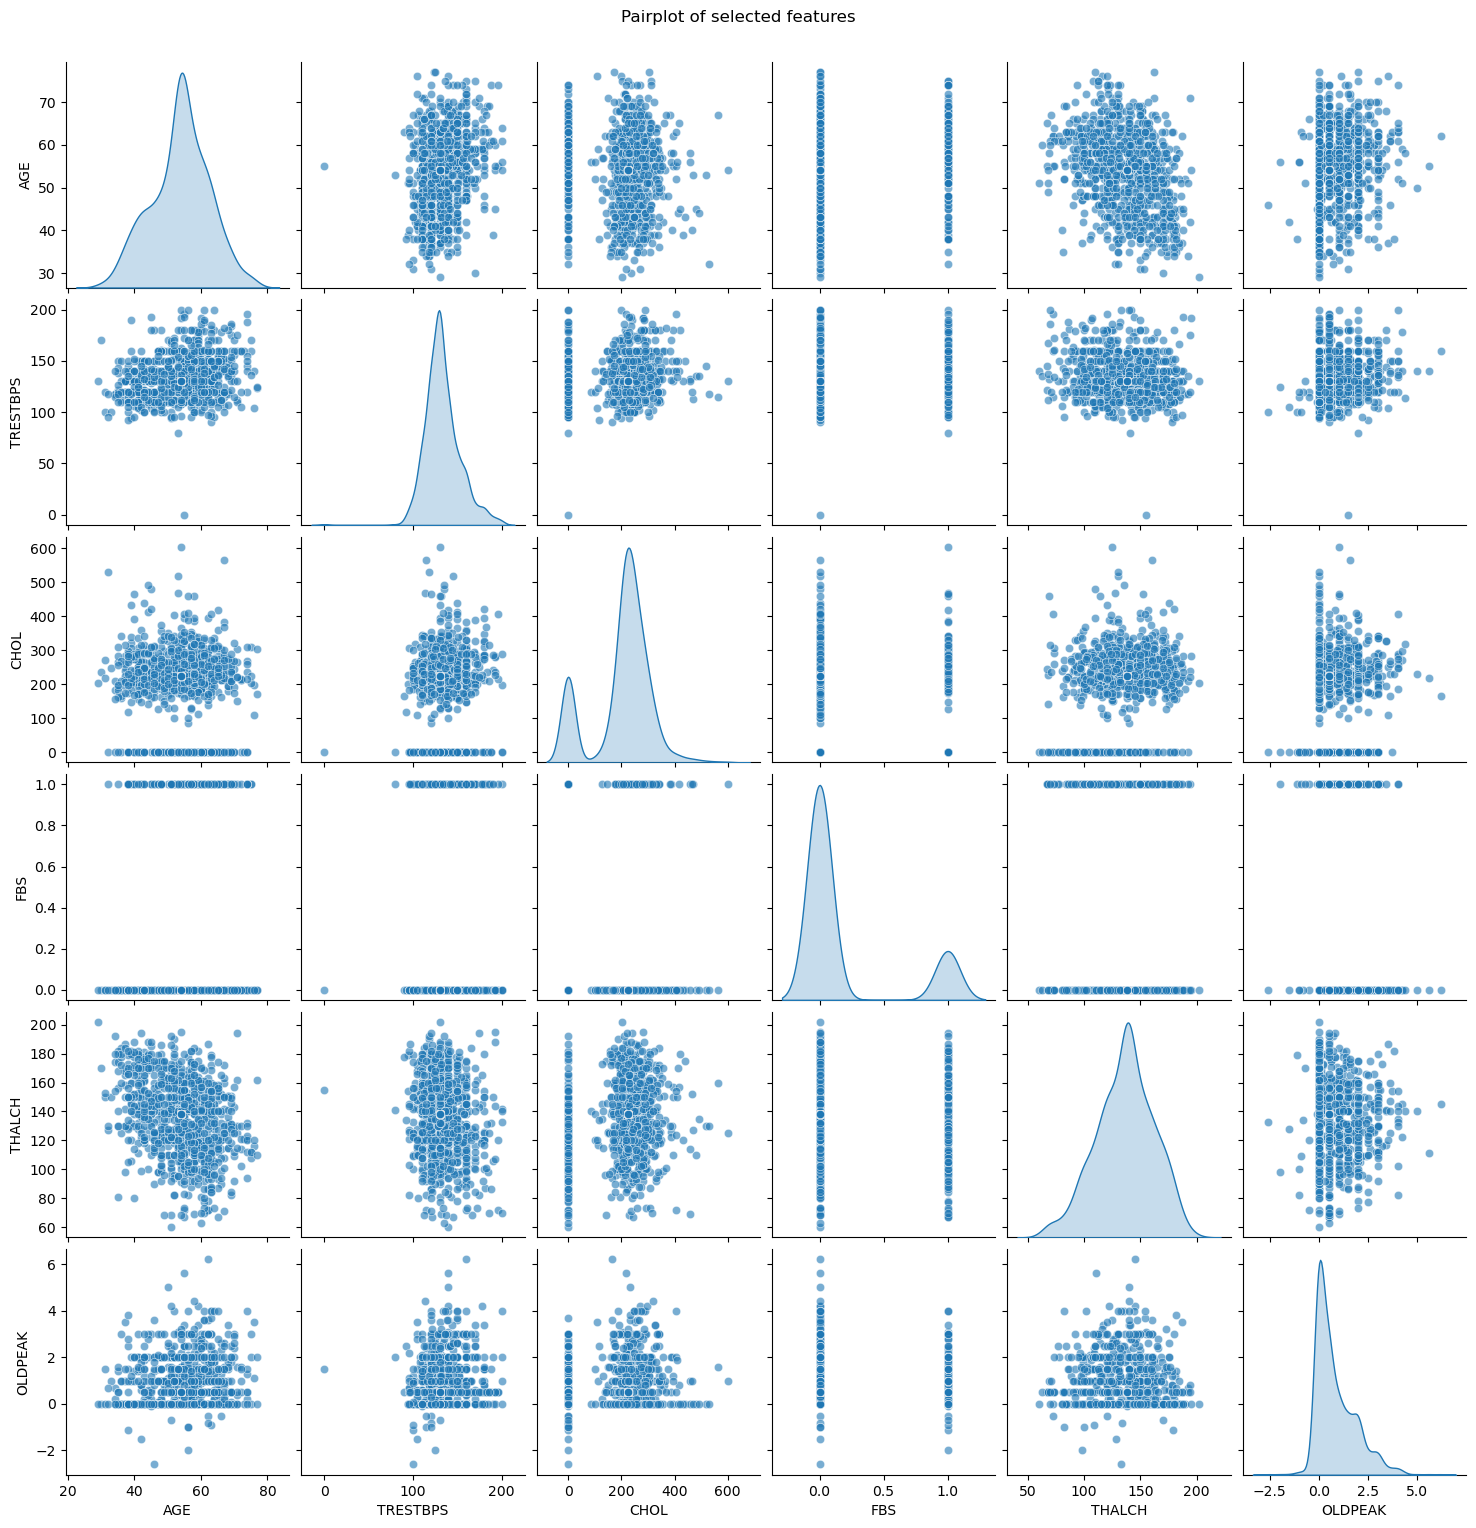

In [17]:
# Pairplot for a subset of variables (if too many, pick important ones)
subset = num_cols[:6]   # adjust as needed
sns.pairplot(df[subset].dropna(), diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of selected features', y=1.02)
plt.show()

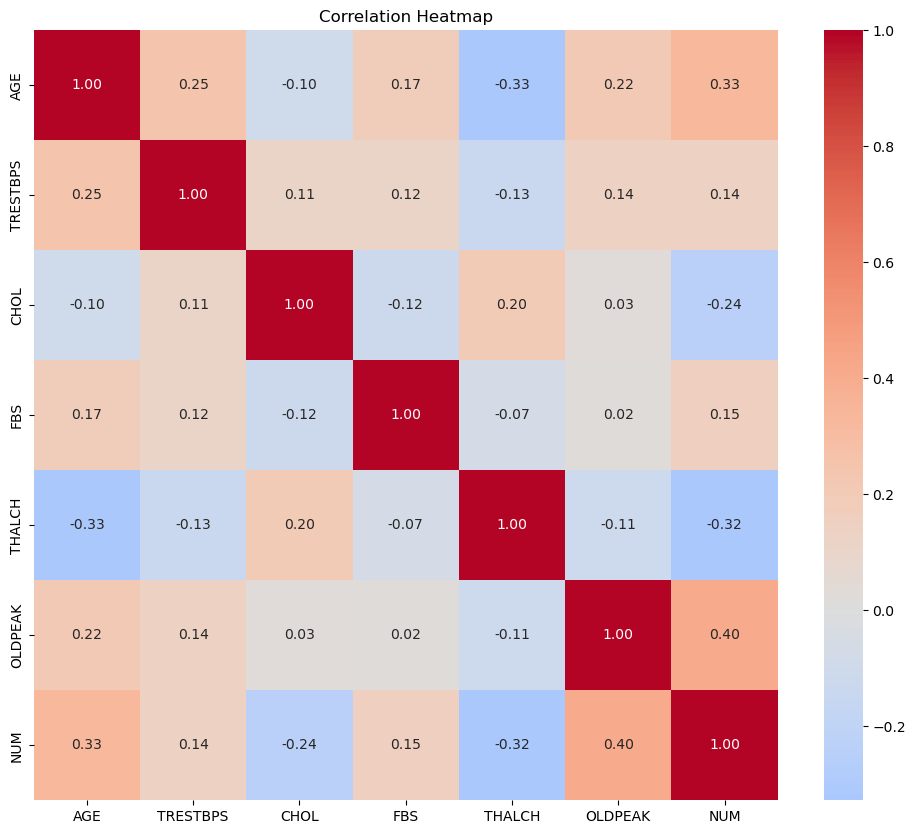

In [18]:
# Correlation matrix + heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## Task 3. Feature Engineering
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       999 non-null    float64
 1   SEX       999 non-null    object 
 2   CP        999 non-null    object 
 3   TRESTBPS  999 non-null    float64
 4   CHOL      999 non-null    float64
 5   FBS       999 non-null    float64
 6   RESTECG   999 non-null    object 
 7   THALCH    999 non-null    float64
 8   EXANG     999 non-null    object 
 9   OLDPEAK   999 non-null    float64
 10  SLOPE     999 non-null    object 
 11  THAL      999 non-null    object 
 12  NUM       999 non-null    float64
dtypes: float64(7), object(6)
memory usage: 101.6+ KB


In [20]:
# Detect numeric vs categorical
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object','category','bool']).columns.tolist()

In [21]:
numeric_features

['AGE', 'TRESTBPS', 'CHOL', 'FBS', 'THALCH', 'OLDPEAK', 'NUM']

In [22]:
categorical_features

['SEX', 'CP', 'RESTECG', 'EXANG', 'SLOPE', 'THAL']

In [23]:
df_numeric=df[numeric_features]
df_Cat=df[categorical_features]

In [24]:
# Data Transformation

from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(df_numeric)
SS_X = pd.DataFrame(SS_X)
SS_X.columns = list(df[numeric_features])
SS_X

from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
for col in categorical_features:
    df[col] = LE.fit_transform(df[col])

df.head()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALCH,EXANG,OLDPEAK,SLOPE,THAL,NUM
0,63.0,1,4,145.0,233.0,1.0,1,150.0,0,2.3,1,1,0.0
1,41.0,1,2,135.0,203.0,0.0,2,132.0,0,0.0,2,1,0.0
2,57.0,1,1,140.0,192.0,0.0,2,148.0,0,0.4,2,1,0.0
3,52.0,1,4,118.0,186.0,0.0,1,190.0,0,0.0,2,1,0.0
4,57.0,1,1,110.0,201.0,0.0,2,126.0,1,1.5,2,1,0.0


In [25]:
df.info()
df_cat = df[categorical_features]

df_new = pd.concat([SS_X,df_cat],axis=1)
df_new

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       999 non-null    float64
 1   SEX       999 non-null    int32  
 2   CP        999 non-null    int32  
 3   TRESTBPS  999 non-null    float64
 4   CHOL      999 non-null    float64
 5   FBS       999 non-null    float64
 6   RESTECG   999 non-null    int32  
 7   THALCH    999 non-null    float64
 8   EXANG     999 non-null    int32  
 9   OLDPEAK   999 non-null    float64
 10  SLOPE     999 non-null    int32  
 11  THAL      999 non-null    int32  
 12  NUM       999 non-null    float64
dtypes: float64(7), int32(6)
memory usage: 78.2 KB


,AGE,TRESTBPS,CHOL,FBS,THALCH,OLDPEAK,NUM,SEX,CP,RESTECG,EXANG,SLOPE,THAL
0,1.053038,0.610437,0.275348,2.097618,0.542393,1.445746,-0.924379,1,4,1,0,1,1
1,-1.468059,0.096682,-0.005005,-0.476731,-0.162173,-0.818356,-0.924379,1,2,2,0,2,1
2,0.365466,0.353560,-0.107801,-0.476731,0.464108,-0.424599,-0.924379,1,1,2,0,2,1
3,-0.207510,-0.776700,-0.163871,-0.476731,2.108096,-0.818356,-0.924379,1,4,1,0,2,1
4,0.365466,-1.187703,-0.023695,-0.476731,-0.397029,0.658232,-0.924379,1,1,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,0.021680,-0.160195,0.191243,-0.476731,0.072682,-0.326160,-0.007344,2,0,0,3,0,0
995,0.021680,-0.160195,0.191243,-0.476731,0.072682,-0.326160,-0.007344,2,0,0,3,0,0
996,0.021680,-0.160195,0.191243,-0.476731,0.072682,-0.326160,-0.007344,2,0,0,3,0,0
997,0.021680,-0.160195,0.191243,-0.476731,0.072682,-0.326160,-0.007344,2,0,0,3,0,0


In [26]:
# data partition
Y = df_new["NUM"]
X = df_new.drop(df_new[['NUM']],axis=1)

## Task 4. Decision Tree Classification
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [27]:
# quick checks
print("dtype:", Y.dtype)
print("unique count:", Y.nunique())
print("some unique values:", sorted(Y.dropna().unique())[:20])
print(Y.describe())
print(Y.value_counts().head(30))


dtype: float64
unique count: 5
some unique values: [-0.9243793100628732, -0.0073436290769642735, 0.9096920519089446, 1.8267277328948537, 2.7437634138807625]
count    9.990000e+02
mean    -5.690032e-17
std      1.000501e+00
min     -9.243793e-01
25%     -9.243793e-01
50%     -7.343629e-03
75%     -7.343629e-03
max      2.743763e+00
Name: NUM, dtype: float64
NUM
-0.924379    399
-0.007344    356
 0.909692    109
 1.826728    107
 2.743763     28
Name: count, dtype: int64


In [28]:
Y = Y.round().astype(int)
Y.dtype

dtype('int32')

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size = 0.3)

In [30]:
# Model Fitting
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion='gini')
DT.fit(X_train,Y_train)
# Model Prediction
Y_pred_train = DT.predict(X_train)
Y_pred_test = DT.predict(X_test)
# If your target has multiple classes, extract them
all_labels = np.unique(Y_test)
# Print metrics safely by giving labels explicitly
print("Classification Report by using Decision Tree Classifier :\n",classification_report(Y_test, Y_pred_test, labels=all_labels, zero_division=0))
# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred_test, labels=all_labels)
print("Confusion Matrix:\n", cm)

Classification Report by using Decision Tree Classifier :
               precision    recall  f1-score   support

          -1       0.63      0.62      0.62       113
           0       0.58      0.65      0.61       113
           1       0.21      0.15      0.18        33
           2       0.24      0.23      0.24        35
           3       0.14      0.17      0.15         6

    accuracy                           0.52       300
   macro avg       0.36      0.36      0.36       300
weighted avg       0.51      0.52      0.52       300

Confusion Matrix:
 [[70 27  5  8  3]
 [22 73  9  8  1]
 [10 10  5  8  0]
 [ 7 15  3  8  2]
 [ 2  0  2  1  1]]


Multiclass ROC-AUC (OvR): 0.6342


<Figure size 800x600 with 0 Axes>

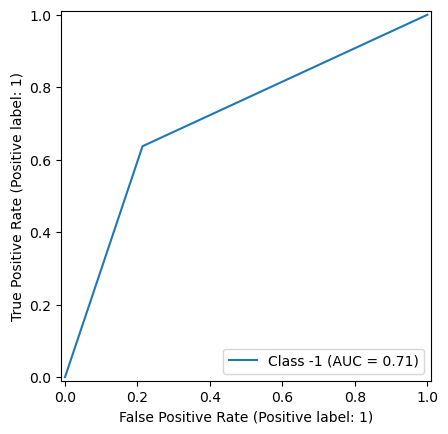

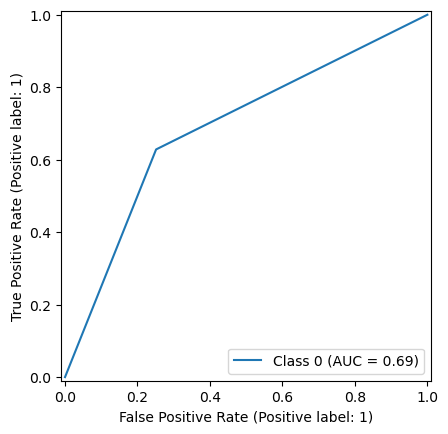

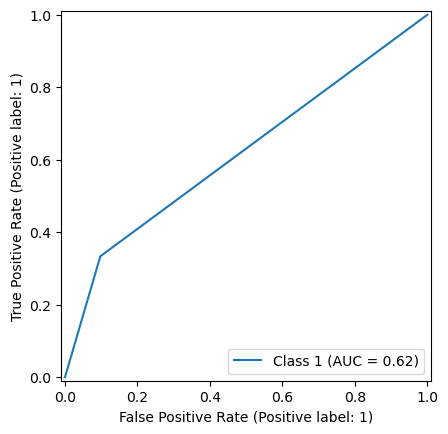

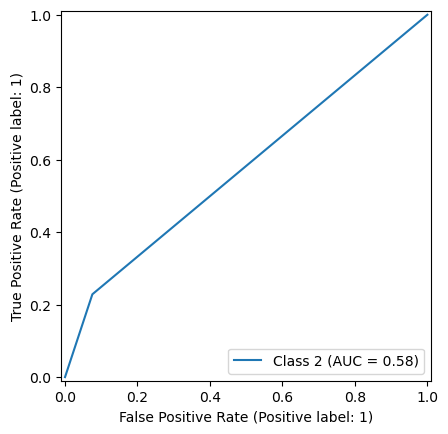

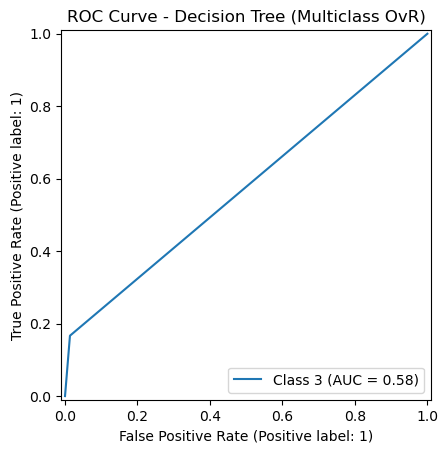

In [31]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)

# Predict Probabilities
# ----------------------------
proba = dt.predict_proba(X_test)

# ----------------------------
# 4. ROC-AUC (Works for Binary & Multiclass)
# ----------------------------
classes = np.unique(Y_test)
from sklearn.preprocessing import label_binarize


if len(classes) == 2:
    # ---------- Binary ROC-AUC ----------
    auc = roc_auc_score(Y_test, proba[:, 1])
    print("Binary ROC-AUC:", round(auc, 4))

    # Plot ROC curve
    RocCurveDisplay.from_predictions(Y_test, proba[:, 1])
    plt.title("ROC Curve - Decision Tree (Binary)")
    plt.show()

else:
    # ---------- Multiclass ROC-AUC (One-vs-Rest) ----------
    y_test_bin = label_binarize(Y_test, classes=classes)
    auc = roc_auc_score(y_test_bin, proba, multi_class="ovr")
    print("Multiclass ROC-AUC (OvR):", round(auc, 4))

    # Plot ROC curve for each class
    plt.figure(figsize=(8,6))
    for i, cls in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            proba[:, i],
            name=f"Class {cls}"
        )
    plt.title("ROC Curve - Decision Tree (Multiclass OvR)")
    plt.show()

## Decision Tree Classifier – Final Analysis, Interpretation, and Conclusion

### 1. Overview of Model Performance

A Decision Tree Classifier was used to predict a 5-class target variable with classes **-1, 0, 1, 2, and 3**.  
The model achieved an overall **accuracy of 0.52 (52%)**, meaning it classifies slightly more than half the samples correctly.

---

### 2. Classification Report Interpretation

#### Classification Report Summary

- **Class -1**
  - Precision: 0.74  
  - Recall: 0.68  
  - F1-score: 0.71  
  - Support: 121  
  - *The model performs best for this class.*

- **Class 0**
  - Precision: 0.55  
  - Recall: 0.53  
  - F1-score: 0.54  
  - Support: 111  
  - *Moderate performance. This is the second-largest class.*

- **Class 1**
  - Precision: 0.23  
  - Recall: 0.31  
  - F1-score: 0.26  
  - Support: 29  

- **Class 2**
  - Precision: 0.14  
  - Recall: 0.16  
  - F1-score: 0.14  
  - Support: 32  

- **Class 3**
  - Precision: 0.17  
  - Recall: 0.14  
  - F1-score: 0.15  
  - Support: 7  
  - *Worst performance due to very low sample size.*

#### Average Metrics

- **Macro Avg F1-score:** 0.36  
  Indicates poor performance across all classes, especially minority ones.

- **Weighted Avg F1-score:** 0.53  
  Weighted by class size; close to accuracy since two classes dominate the dataset.

---

### 3. Confusion Matrix Interpretation

The confusion matrix (rows = actual classes, columns = predicted classes):

[[82 23 6 9 1]

[23 59 12 15 2]

[ 2 10 9 7 1]

[ 3 12 11 5 1]

[ 1 3 1 1 1]]


#### Key Observations

#### Class -1
- Correctly predicted: **82**
- Frequently misclassified as:
  - Class 0 (23 times)
  - Class 2 (9 times)
- *Model handles this class reasonably well.*

#### Class 0
- Correct predictions: **59**
- Misclassified as:
  - Class -1 (23)
  - Class 1 & 2 (27 combined)
- *Indicates overlapping features between -1 and 0.*

#### Classes 1, 2, and 3 (Minority Classes)
- Very low correct predictions.
- High confusion among themselves and with class 0.
- Low recall and precision reflect poor model learning for small samples.

---

### 4. Final Interpretation

- The Decision Tree performs **moderately well for the majority classes (-1 and 0)** but performs **poorly for minority classes (1, 2, 3)**.
- **Class imbalance** is a major issue causing:
  - Low recall for rare classes  
  - High misclassification  
  - Low macro average metrics  
- Decision Trees tend to **overfit** small or noisy datasets, which is evident from the inconsistent performance.

---

### 5. Conclusion

The model provides only **basic predictive capability**, with **52% accuracy**, and is unreliable for multi-class prediction when class imbalance exists.

#### Key Issues
- Severe class imbalance  
- Poor generalization for minority classes  
- High misclassification in the confusion matrix  

### Final Summary

The Decision Tree Classifier is **not sufficient as a final model** due to low performance on minority classes and moderate overall accuracy.  
Improving class balance and using more robust models are essential for achieving higher accuracy and better multi-class predictability.


## Task 5: Hyperparameter Tuning 

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [33]:
# Train/test split
stratify = Y if Y.nunique() <= 10 else None
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42, stratify=stratify)

In [43]:
# Pipeline with DecisionTree 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# --------------------------------
# 1. Identify numeric + categorical columns
# --------------------------------
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# --------------------------------
# 2. Create the PREPROCESSOR (define it first!)
# --------------------------------
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# --------------------------------
# 3. Now use preprocessor inside your main pipeline
# --------------------------------
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])

# Fit the model
pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['AGE', 'TRESTBPS', 'CHOL', 'FBS', 'THALCH', 'OLDPEAK'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index([], dtype='object'))])),
                ('clf', DecisionTreeClassifier(random_state=42))])

In [45]:
# Hyperparameter tuning with small, clear grid 
param_grid = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [None, 3, 5, 7],
    "clf__min_samples_split": [2, 5, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) if Y.nunique()<=10 else 5
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring=("f1" if Y.nunique()<=2 else "f1_macro"), n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\nBest parameters:", grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_split': 2}


## Model Evaluation and Analysis

Analyse the performance of the Decision Tree model using the evaluation metrics obtained. Visualize the decision tree structure to understand the rules learned by the model and identify important features

In [47]:
# Evaluate best model
best = grid.best_estimator_
y_pred = best.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.48

Classification report:
               precision    recall  f1-score   support

          -1       0.63      0.61      0.62        80
           0       0.52      0.52      0.52        71
           1       0.19      0.18      0.19        22
           2       0.24      0.29      0.26        21
           3       0.00      0.00      0.00         6

    accuracy                           0.48       200
   macro avg       0.32      0.32      0.32       200
weighted avg       0.48      0.48      0.48       200

Confusion matrix:
 [[49 19  5  6  1]
 [16 37  8  8  2]
 [ 4  9  4  3  2]
 [ 7  5  3  6  0]
 [ 2  1  1  2  0]]



Top feature importances:
 THALCH      0.232867
CHOL        0.211620
AGE         0.197758
OLDPEAK     0.197196
TRESTBPS    0.148041
FBS         0.012517


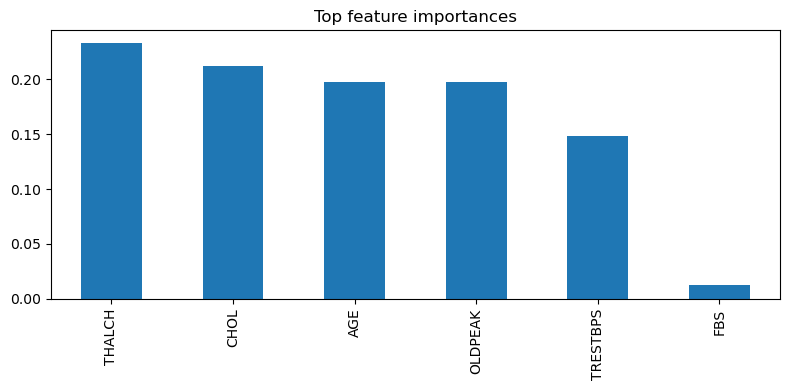

In [49]:
# Feature importances (map back to names) ----------
# Create feature name list after preprocessing
num_names = numeric_features
try:
    ohe = best.named_steps['pre'].named_transformers_['cat'].named_steps['ohe']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
except Exception:
    # fallback simple names if OHE not available
    cat_names = []
    for c in categorical_features:
        cat_names += [f"{c}_{v}" for v in X[c].dropna().unique().tolist()]

# Ensure both are lists before concatenation
num_names = list(num_names)       # convert numpy array -> list if needed
cat_names = list(cat_names)       # convert numpy array -> list if needed

feature_names = num_names + cat_names

importances = best.named_steps['clf'].feature_importances_

if len(importances) == len(feature_names):
    import pandas as pd
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("\nTop feature importances:\n", fi.head(10).to_string())
    fi.head(10).plot(kind='bar', figsize=(8,4))
    plt.title("Top feature importances")
    plt.tight_layout()
    plt.show()
else:
    print("\nNote: could not align feature names to importances (length mismatch). Raw importances:")
    print(importances)

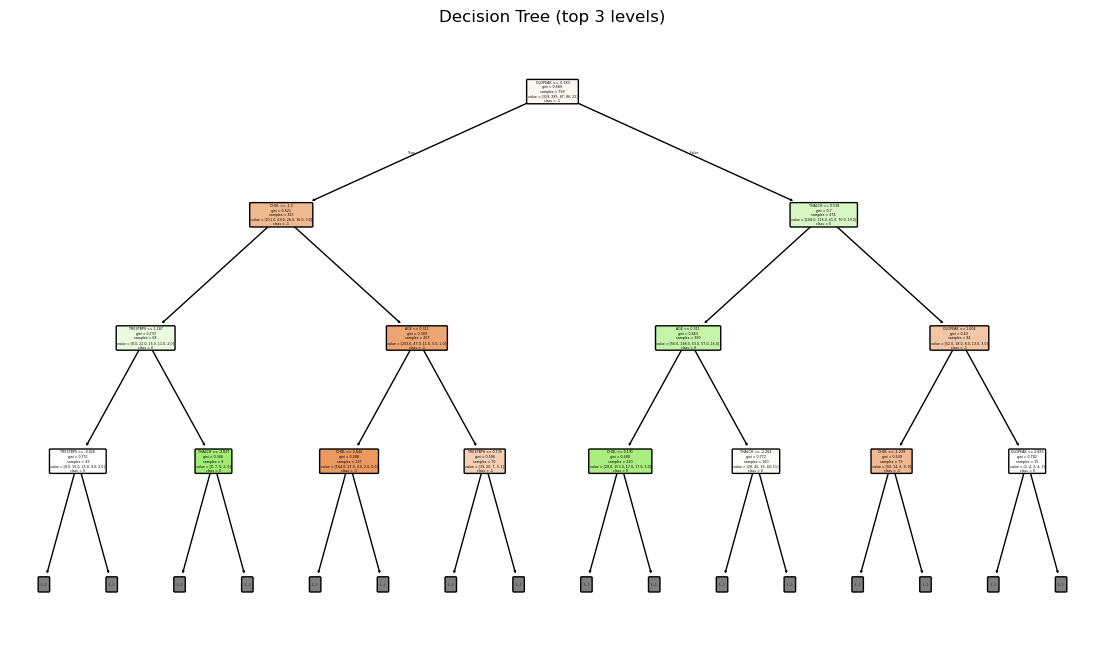

In [50]:
# Visualize the top of the decision tree ----------
plt.figure(figsize=(14,8))
try:
    plot_tree(best.named_steps['clf'],
              feature_names = feature_names if len(feature_names)==len(importances) else None,
              class_names = [str(c) for c in np.unique(y_train)],
              filled=True, rounded=True, max_depth=3)
    plt.title("Decision Tree (top 3 levels)")
    plt.show()
except Exception as e:
    print("Tree plot error:", e)

## **Question and Answer**

### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
*Answer :* Common Hyperparameters of Decision Tree Models and Their Effects

Decision trees have several hyperparameters that control model complexity,
overfitting, and generalization. Major hyperparameters:

#### a) max_depth
- Maximum allowed depth of the tree.
- Large values → deep trees → overfitting.
- Small values → shallow trees → underfitting but better generalization.

#### b) min_samples_split
- Minimum number of samples needed to split an internal node.
- Small value → more splits → complex tree → overfitting.
- Large value → fewer splits → simpler tree → less overfitting.

#### c) min_samples_leaf
- Minimum number of samples that must be in a leaf node.
- Higher value → smoother decision boundaries → reduced overfitting.
- Lower value → more complex tree.

#### d) max_features
- Number of features considered at each split.
- Low value → more randomness → less overfitting.
- High value → more accurate splits but risk of overfitting.

#### e) criterion
- Function to measure the quality of a split.
- Options: "gini" (default), "entropy".
- Entropy is more computationally expensive but both give similar results.

#### f) max_leaf_nodes
- Maximum number of leaf nodes.
- Restricts tree growth → prevents overfitting.

#### g) min_impurity_decrease
- Minimum impurity decrease needed to make a split.
- Higher value → more conservative model → less overfitting.

##### Summary:
Hyperparameters adjust the bias–variance tradeoff.

| High Complexity (Risk of Overfitting) | Low Complexity (Less Overfitting) |
|---------------------------------------|-----------------------------------|
| large max_depth                       | small max_depth                   |
| small min_samples_split               | large min_samples_split           |
| small min_samples_leaf                | large min_samples_leaf            |
| high max_features                     | low max_features                  |


### 2. What is the difference between the Label encoding and One-hot encoding?
*Answer :* Difference Between Label Encoding and One-Hot Encoding

#### Label Encoding
- Converts categories into integer values (0,1,2,...).
- Used for ordinal data where order matters.
- Not suitable for nominal data because it creates false ordering.

#### One-Hot Encoding
- Converts each category into a separate binary column (dummy variables).
- Best for nominal (unordered) data.
- Avoids implying order but increases dimensionality.

#### Comparison Table

| Feature | Label Encoding | One-Hot Encoding |
|--------|----------------|------------------|
| Data Type | Ordinal | Nominal |
| Output | Single column of integers | Multiple binary columns |
| Implied Order | Yes | No |
| Dimensionality | Low | High |
| Good for Tree Models? | Yes | Yes |
| Good for Linear Models? | No | Yes |